# Section 4: Model Performance Optimization --> Chapter 17: Decision Tree


---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
# In case you need to install the relevent packages, please uncomment lines below and run (once only)

!pip install scikit-learn==1.2.2
!pip install pandas==2.0.3
!pip install numpy==1.25.2
!pip install matplotlib==3.7.1
!pip install pydrive2==1.6.3

---

☑ **Import libraries**

---

In [ ]:
# Standard Library Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

from sklearn.dummy import DummyClassifier
from sklearn import tree
from sklearn.tree import *
from sklearn.ensemble import *
from sklearn.neighbors import *
from sklearn.naive_bayes import *
from sklearn.linear_model import *
from sklearn.preprocessing import *
from sklearn.pipeline import *
from sklearn.decomposition import *
from sklearn import metrics
from sklearn.model_selection import *
from sklearn.metrics import *
from sklearn.utils.multiclass import type_of_target

# To suppress all warnings:
import warnings
warnings.filterwarnings("ignore")

## 4.1 Single Output Decision Tree Regressor

####################################################################################################

                                      Decision Tree Regressors                                      

####################################################################################################

Training and evaluating :  DecisionTreeRegressor


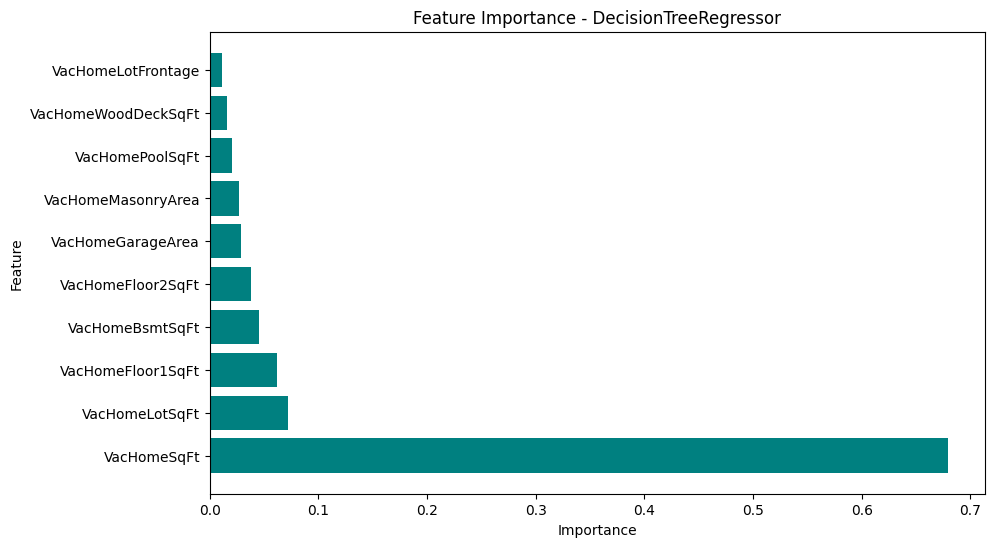

Training and evaluating :  ExtraTreeRegressor


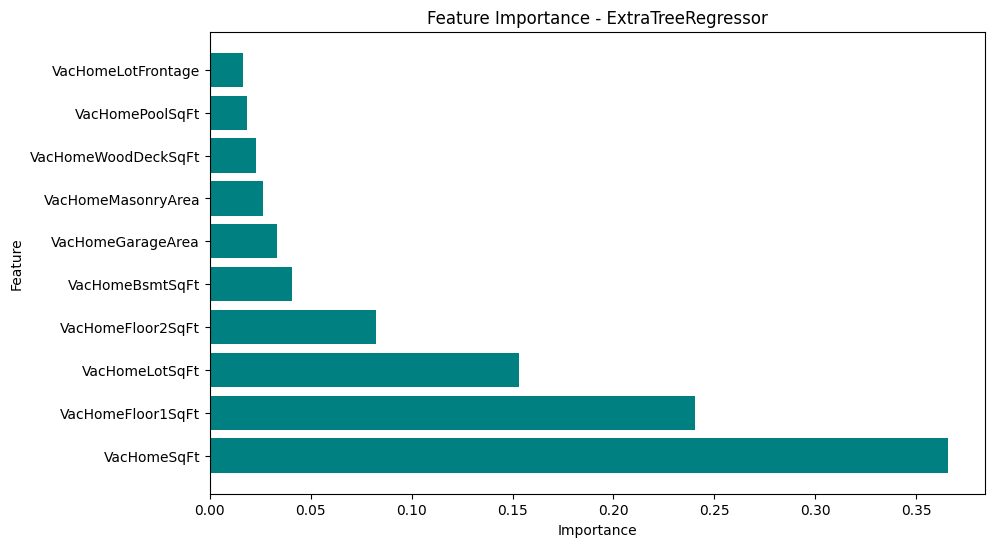

In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():

    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():

    target_column = 'VacHomeSalePrice'

    regression_evaluation_columns = ['Data', 'Algorithm', 'Model_Changed', 'Iteration', 'explained_variance',
                                      'max_error', 'neg_mean_absolute_error', 'neg_mean_squared_error',
                                      'neg_root_mean_squared_error', 'neg_mean_squared_log_error',
                                      'neg_median_absolute_error', 'r2', 'neg_mean_poisson_deviance',
                                       'neg_mean_absolute_percentage_error',
                                      'duration']

    continuous_columns = [
        'VacHomeLotFrontage', 'VacHomeLotSqFt', 'VacHomeBsmtSqFt', 'VacHomeFloor1SqFt',
        'VacHomeFloor2SqFt', 'VacHomeSqFt', 'VacHomeGarageArea', 'VacHomeWoodDeckSqFt', 'VacHomePorchSqFt',
        'VacHomePoolSqFt',  'VacHomeMasonryArea', 'VacHomeRenovationAmount'
    ]

    nominal_columns = [
        'VacHomeLotShape', 'VacHomeLandContour', 'VacHomeLotConfig', 'VacHomeLandSlope',
        'VacHomeNeighborhood', 'VacHomeCondition', 'VacHomeBuilding', 'VacHomeRoofStyle',
        'VacHomeMasonryVeneer', 'VacHomeFoundation', 'VacHomeBsmtLight', 'VacHomeBsmtFinish',
        'VacHomeAC', 'VacHomeGarageType', 'VacHomeGarageFinish', 'VacHomeDriveway', 'VacHomeFence',
        'VacHomeSaleCondition', 'VacHomeGoodSchools', 'VacHomeOwnerGender', 'VacHomeOwnerState','VacHomeInterestInHome'
    ]

    ordinal_columns = [
        'VacHomeRating', 'VacHomeQuality', 'VacHomeExterQual', 'VacHomeQual', 'VacHomeBsmtQuality',
        'VacHomeHeatingQuality', 'VacHomeFireplaceQuality', 'VacHomeGarageQuality', 'VacHomeSurveyRating'
    ]

    ignore_columns = [
        'VacationHomeID', 'VacHomeStreet', 'VacHomeRoad', 'VacHomeConsYear', 'VacHomeSince',
        'VacHomeStartMonth', 'VacHomeStartYear', 'VacHomeAvailableDate', 'VacHomeBarCode',
        'VacHomeOwnerAddress', 'VacHomeOwnerEmail', 'VacHomeSurveyDate', 'VacHomeNumFullBath',
        'VacHomeNumHalfBath', 'VacHomeBedroomWithCloset', 'VacHomeKitcheninHome', 'VacHomeRooms',
        'VacHomeFireplaces', 'VacHomeCarsInGarage', 'VacHomeClass', 'VacHomeExterior', 'VacHomeSaleType',
        'VacHomeHouseStyle', 'VacHomeUtilities', 'VacHomeElectricalWiring', 'VacHomeZone', 'VacHomeHeating',
        'VacHomeOwnerZipcode', 'VacHomeRoofMat', 'VacHomeOwnerCity', 'VacHomeOwnerCountry', 'VacHomePoolQuality',
        'VacHomeKitchenQuality','VacHomeReviewDate'
    ]
    return regression_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column

# Function to Split Data
def _3_split_data(df_rawdata, target_column):
    # target_column = 'VacHomeSalePrice'
    if target_column not in df_rawdata.columns:
        raise KeyError(f"Target column '{target_column}' not found in the DataFrame.")

    # Calculate the number of rows needed for the training set (50%)
    training_size = len(df_rawdata) // 2

    # Slice the data to create the training and test sets
    df_train_data = df_rawdata.iloc[:training_size]
    df_test_data = df_rawdata.iloc[training_size:]

    y_split_train = df_train_data[target_column].values
    X_split_train = df_train_data.drop(columns=target_column)
    y_split_test = df_test_data[target_column].values
    X_split_test = df_test_data.drop(columns=target_column)
    return X_split_train, y_split_train, X_split_test, y_split_test


# Functions for Data Processing and Encoding
def _4_preprocess_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    # Impute NaN values
    for col in continuous_columns:
        train_data[col].fillna(train_data[col].mean(), inplace=True)
        test_data[col].fillna(train_data[col].mean(), inplace=True)

    for col in nominal_columns:
        train_data[col].fillna("Unknown", inplace=True)
        test_data[col].fillna("Unknown", inplace=True)

    for col in ordinal_columns:
        train_data[col].fillna(15, inplace=True)
        test_data[col] = test_data[col].apply(lambda x: 15 if x == 'N' else x)
        test_data[col].fillna(15, inplace=True)

    train_preprocessed_data = train_data.drop(columns=ignore_columns)
    test_preprocessed_data = test_data.drop(columns=ignore_columns)
    return train_preprocessed_data, test_preprocessed_data

# Function to Encode Data
def _5_encode_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    label_encoder = LabelEncoder()
    for col in ordinal_columns:
        train_data[col] = label_encoder.fit_transform(train_data[col].astype(str))
        test_data[col] = label_encoder.transform(test_data[col].astype(str))

    for col in nominal_columns:
        if col in train_data.columns and col in test_data.columns:
            train_data[col] = label_encoder.fit_transform(train_data[col])
            test_data[col] = label_encoder.transform(test_data[col])

    train_encoded_data = pd.get_dummies(train_data, columns=nominal_columns, drop_first=True)
    test_encoded_data = pd.get_dummies(test_data, columns=nominal_columns, drop_first=True)

    return train_encoded_data, test_encoded_data

# Function to PCA
def _7_run_pca(X_train_encoded, X_test_encoded, original_feature_names):
    # Define the number of components you want to keep
    n_components = 10  # You can choose a suitable number

    # Initialize PCA and fit on your data
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_encoded)  # Fit and transform training data
    X_test_pca = pca.fit_transform(X_test_encoded)  # Transform test data using the same PCA model

    # Get the real feature names after PCA
    pca_feature_names = [f"{original_feature_names[j]}" for i, j in zip(range(n_components), pca.components_.argsort()[:, ::-1][:, :n_components].flatten())]

    return X_train_pca, X_test_pca, pca_feature_names

def append_result_df(result_df, data, algo_name, model_change, iteration_number, y_true, y_pred, duration):
    result_row = {
        'Data': data,
        'Algorithm': algo_name,
        'Model_Changed': model_change,
        'Iteration': iteration_number,
        'duration': duration
    }

    # Accuracy Metrics
    result_row['explained_variance'] = explained_variance_score(y_true, y_pred)
    result_row['max_error'] = max_error(y_true, y_pred)

    # Error Metrics
    result_row['neg_mean_absolute_error'] = -mean_absolute_error(y_true, y_pred)
    result_row['neg_mean_squared_error'] = -mean_squared_error(y_true, y_pred)
    result_row['neg_root_mean_squared_error'] = -np.sqrt(mean_squared_error(y_true, y_pred))

    if (y_true >= 0).all() and (y_pred >= 0).all():
        # Only calculate these metrics if all values are non-negative
        result_row['neg_mean_squared_log_error'] = -mean_squared_log_error(y_true, y_pred)
        result_row['neg_median_absolute_error'] = -median_absolute_error(y_true, y_pred)

        # Goodness of Fit
        result_row['r2'] = r2_score(y_true, y_pred)
        result_row['neg_mean_poisson_deviance'] = -mean_poisson_deviance(y_true, y_pred)
        result_row['neg_mean_absolute_percentage_error'] = -mean_absolute_percentage_error(y_true, y_pred)
    else:
        # If any value is negative, set these metrics to NaN or a custom value
        result_row['neg_mean_squared_log_error'] = None
        result_row['neg_median_absolute_error'] = None

        # Goodness of Fit
        result_row['r2'] = None
        result_row['neg_mean_poisson_deviance'] = None
        result_row['neg_mean_absolute_percentage_error'] = None

    result_df = pd.concat([result_df, pd.DataFrame([result_row])], ignore_index=True)
    return result_df


def _9_evaluation_regressors(reg_name, feature_importances, feature_names):
    # Ensure feature names and importances have the same length
    if len(feature_names) != len(feature_importances):
        raise ValueError("Lengths of feature_names and feature_importances must be the same")

    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

    # Sort the DataFrame by importance
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Plot the feature importances
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
    plt.title(f'Feature Importance - {reg_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

    return

# Function to Train Decision Tree Regressor
def _8_train_regressors(X_train, y_train, X_test, y_test, regression_result_df, feature_names):
    # Define regression algorithms
    regressors = {
        'DecisionTreeRegressor': DecisionTreeRegressor(),
        'ExtraTreeRegressor': ExtraTreeRegressor()
    }

    # Define variables outside the loop
    tree_depth, node_count, ccp_path = None, None, None

    # Loop through regression algorithms
    for i, (reg_name, reg) in enumerate(regressors.items()):
        print(f"Training and evaluating :  {reg_name}")  # Add a progress message

        start_time = time.time()

        # Fit the regression algorithm on the training data
        regressor = reg.fit(X_train, y_train)
        feature_importances = regressor.feature_importances_

        # Get tree information (calculated only for the training set)
        tree_depth = regressor.get_depth()
        node_count = regressor.tree_.node_count
        ccp_path_train = regressor.cost_complexity_pruning_path(X_train, y_train).ccp_alphas
        ccp_path_test = regressor.cost_complexity_pruning_path(X_test, y_test).ccp_alphas

        # Visualize feature importance
        _9_evaluation_regressors(reg_name, feature_importances, feature_names)

        y_pred_train = reg.predict(X_train)
        y_pred_test = reg.predict(X_test)
        # Pause the clock
        end_time = time.time()
        duration = round(end_time - start_time, ndigits=4)

        # Add tree information to the result DataFrame
        regression_result_df = append_result_df(regression_result_df, "Training Set", reg_name, "New Algorithm", 1, y_train, y_pred_train, duration)
        regression_result_df = append_result_df(regression_result_df, "Test Set", reg_name, "New Algorithm", 1, y_test, y_pred_test, duration)

        # Assign tree information directly to the DataFrame
        regression_result_df.loc[regression_result_df['Algorithm'] == reg_name, 'tree_depth'] = tree_depth
        regression_result_df.loc[regression_result_df['Algorithm'] == reg_name, 'node_count'] = node_count

    return regression_result_df

# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Training Data
    df_rawdata = _1_get_data()

    # Step 2. Define Variables
    regression_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column = _2_define_variables()
    regression_result_df = pd.DataFrame(columns=regression_evaluation_columns)

    # Split data
    X_split_train, y_split_train, X_split_test, y_split_test = _3_split_data(df_rawdata, target_column)

    train_preprocessed_data, test_preprocessed_data = _4_preprocess_data(X_split_train, X_split_test, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 5. Encode data
    X_train_encoded, X_test_encoded = _5_encode_data(train_preprocessed_data, test_preprocessed_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 7. Run PCA for dimensionality reduction
    X_train_pca, X_test_pca, pca_feature_names = _7_run_pca(X_train_encoded, X_test_encoded, X_train_encoded.columns)

    # Train and evaluate the model
    regression_result_df = _8_train_regressors(X_train_pca, y_split_train, X_test_pca, y_split_test, regression_result_df, pca_feature_names)

    # Time taken by model
    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)
    return regression_result_df

if __name__ == "__main__":
    # Print Header
    print_pretty_header("Decision Tree Regressors", "")
    regression_result_df = main()  # Call main() and store the result in regressor_result_df
    regression_result_df  # Now you can access regressor_result_df


In [ ]:
# Print Header
print_pretty_header("Decision Tree Regressors", "Evaluation Metrics")
# Display the DataFrame
regression_result_df.sort_values(by='Data', ascending=False, inplace=True)
regression_result_df

####################################################################################################

                                      Decision Tree Regressors                                      

                                         Evaluation Metrics                                         

####################################################################################################



,Data,Algorithm,Model_Changed,Iteration,explained_variance,max_error,neg_mean_absolute_error,neg_mean_squared_error,neg_root_mean_squared_error,neg_mean_squared_log_error,neg_median_absolute_error,r2,neg_mean_poisson_deviance,neg_mean_absolute_percentage_error,duration,tree_depth,node_count
0,Training Set,DecisionTreeRegressor,New Algorithm,1,1.000000,0.0,-0.000000,-0.000000e+00,-0.000000,-0.000000,-0.00,1.000000,-0.000000,-0.000000,0.6992,23.0,1411.0
2,Training Set,ExtraTreeRegressor,New Algorithm,1,1.000000,0.0,-0.000000,-0.000000e+00,-0.000000,-0.000000,-0.00,1.000000,-0.000000,-0.000000,0.4325,27.0,1439.0
1,Test Set,DecisionTreeRegressor,New Algorithm,1,0.376833,317890.0,-35779.016932,-2.572743e+09,-50722.215670,-0.103151,-24941.50,0.367953,-14714.884969,-0.262086,0.6992,23.0,1411.0
3,Test Set,ExtraTreeRegressor,New Algorithm,1,0.082391,493891.5,-40969.128589,-3.753535e+09,-61266.103992,-0.126023,-27754.37,0.077867,-19311.428901,-0.288541,0.4325,27.0,1439.0


####################################################################################################

                                      Decision Tree Regressors                                      

                                         Explained variance                                         

####################################################################################################



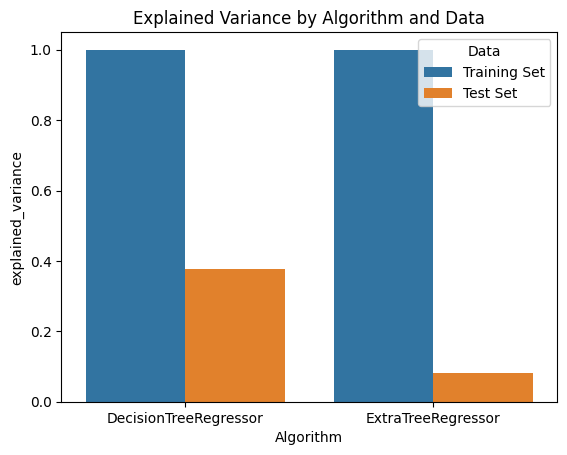

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Print Header
print_pretty_header("Decision Tree Regressors", "Explained variance")

# Assuming 'regression_result_df' is already populated
sns.barplot(x='Algorithm', y='explained_variance', hue='Data', data=regression_result_df)
plt.title('Explained Variance by Algorithm and Data')
plt.show()


## 4.2 Single Output Decision Tree Classifier

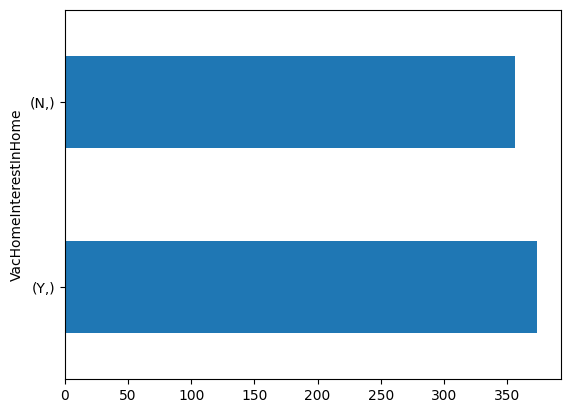

DecisionTreeClassifier


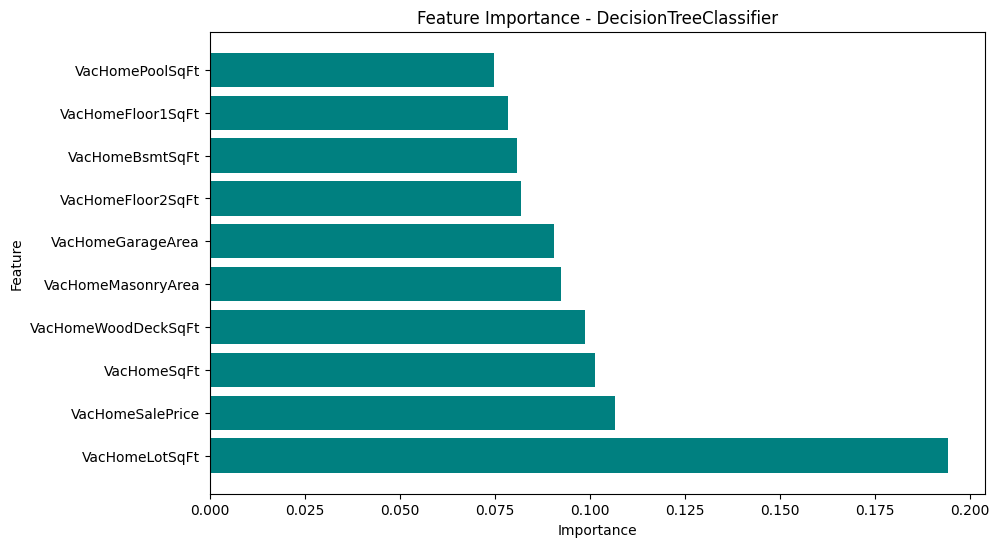

ExtraTreeClassifier


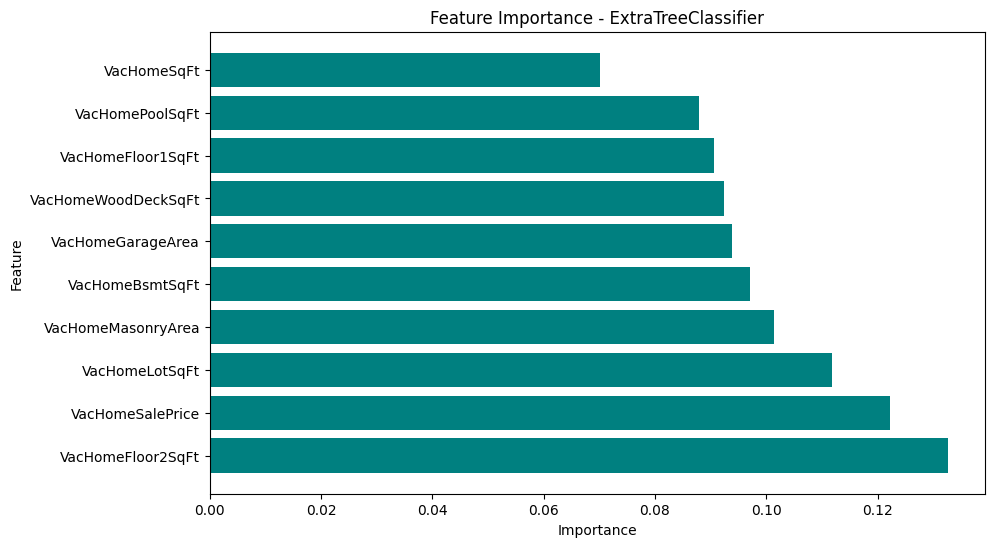

In [ ]:
# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id':id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():

    target_column = 'VacHomeInterestInHome'

    binary_evaluation_columns = ['Data', 'Algorithm', 'Recall', 'Precision', 'Accuracy', 'Balanced Accuracy',
                          'False Positive Rate', 'False Negative Rate', 'True Negative Rate',
                          'Negative Predictive Value', 'False Discovery Rate', 'Duration']

    continuous_columns = [
        'VacHomeLotFrontage', 'VacHomeLotSqFt', 'VacHomeBsmtSqFt', 'VacHomeFloor1SqFt',
        'VacHomeFloor2SqFt', 'VacHomeSqFt', 'VacHomeGarageArea', 'VacHomeWoodDeckSqFt', 'VacHomePorchSqFt',
        'VacHomePoolSqFt', 'VacHomeSalePrice', 'VacHomeMasonryArea', 'VacHomeRenovationAmount'
    ]

    nominal_columns = [
        'VacHomeLotShape', 'VacHomeLandContour', 'VacHomeLotConfig', 'VacHomeLandSlope',
        'VacHomeNeighborhood', 'VacHomeCondition', 'VacHomeBuilding', 'VacHomeRoofStyle',
        'VacHomeMasonryVeneer', 'VacHomeFoundation', 'VacHomeBsmtLight', 'VacHomeBsmtFinish',
        'VacHomeAC', 'VacHomeGarageType', 'VacHomeGarageFinish', 'VacHomeDriveway', 'VacHomeFence',
        'VacHomeSaleCondition', 'VacHomeGoodSchools', 'VacHomeOwnerGender', 'VacHomeOwnerState'
    ]

    ordinal_columns = [
        'VacHomeRating', 'VacHomeQuality', 'VacHomeExterQual', 'VacHomeQual', 'VacHomeBsmtQuality',
        'VacHomeHeatingQuality', 'VacHomeFireplaceQuality', 'VacHomeGarageQuality', 'VacHomeSurveyRating'
    ]

    ignore_columns = [
        'VacationHomeID', 'VacHomeStreet', 'VacHomeRoad', 'VacHomeConsYear', 'VacHomeSince',
        'VacHomeStartMonth', 'VacHomeStartYear', 'VacHomeAvailableDate', 'VacHomeBarCode',
        'VacHomeOwnerAddress', 'VacHomeOwnerEmail', 'VacHomeSurveyDate', 'VacHomeNumFullBath',
        'VacHomeNumHalfBath', 'VacHomeBedroomWithCloset', 'VacHomeKitcheninHome', 'VacHomeRooms',
        'VacHomeFireplaces', 'VacHomeCarsInGarage', 'VacHomeClass', 'VacHomeExterior', 'VacHomeSaleType',
        'VacHomeHouseStyle', 'VacHomeUtilities', 'VacHomeElectricalWiring', 'VacHomeZone', 'VacHomeHeating',
        'VacHomeOwnerZipcode', 'VacHomeRoofMat', 'VacHomeOwnerCity', 'VacHomeOwnerCountry', 'VacHomePoolQuality',
        'VacHomeKitchenQuality','VacHomeReviewDate'
    ]
    return binary_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column

# Function to Split Data
def _3_split_data(df_rawdata):
    target_column = 'VacHomeInterestInHome'
    # Calculate the number of rows needed for the training set (50%)
    training_size = len(df_rawdata) // 2

    # Slice the data to create the training and test sets
    df_train_data = df_rawdata.iloc[:training_size]
    df_test_data = df_rawdata.iloc[training_size:]

    # Map 'N' to 0 and 'Y' to 1 for the target variable
    df_train_data[target_column] = df_train_data[target_column].map({'N': 0, 'Y': 1})
    df_test_data[target_column] = df_test_data[target_column].map({'N': 0, 'Y': 1})

    y_split_train = df_train_data[target_column].values
    X_split_train = df_train_data.drop(columns=target_column)
    y_split_test = df_test_data[target_column].values
    X_split_test = df_test_data.drop(columns=target_column)
    return X_split_train, y_split_train, X_split_test, y_split_test

# Functions for Data Processing and Encoding
def _4_preprocess_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    # Impute NaN values
    for col in continuous_columns:
        train_data[col].fillna(train_data[col].mean(), inplace=True)
        test_data[col].fillna(train_data[col].mean(), inplace=True)

    for col in nominal_columns:
        train_data[col].fillna("Unknown", inplace=True)
        test_data[col].fillna("Unknown", inplace=True)

    for col in ordinal_columns:
        train_data[col].fillna(15, inplace=True)
        test_data[col] = ['N' if label == '0' else label for label in test_data[col]]
        test_data[col].fillna(15, inplace=True)

    train_preprocessed_data = train_data.drop(columns=ignore_columns)
    test_preprocessed_data = test_data.drop(columns=ignore_columns)
    return train_preprocessed_data, test_preprocessed_data

# Function to Encode Data
def _5_encode_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    label_encoder = LabelEncoder()
    for col in ordinal_columns:
        train_data[col] = label_encoder.fit_transform(train_data[col].astype(str))
        test_data[col] = label_encoder.transform(test_data[col].astype(str))

    for col in nominal_columns:
        if col in train_data.columns and col in test_data.columns:
            train_data[col] = label_encoder.fit_transform(train_data[col])
            test_data[col] = label_encoder.transform(test_data[col])

    train_encoded_data = pd.get_dummies(train_data, columns=nominal_columns, drop_first=True)
    test_encoded_data = pd.get_dummies(test_data, columns=nominal_columns, drop_first=True)

    return train_encoded_data, test_encoded_data

def _6_check_for_imbalanced_data(y_split_train):
    df_train_data = pd.DataFrame({'VacHomeInterestInHome': y_split_train})  # Convert the NumPy array to a DataFrame
    df_train_data['VacHomeInterestInHome'] = df_train_data['VacHomeInterestInHome'].replace({1: 'Y', 0: 'N'})

    # Rest of your code
    df_train_data.value_counts().plot(kind='barh')
    plt.show()
    return

# Function to PCA
def _7_run_pca(X_train_encoded, X_test_encoded, original_feature_names):

    # Define the number of components you want to keep
    n_components = 10  # You can choose a suitable number

    # Initialize PCA and fit on your data
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_encoded)  # Fit and transform training data
    X_test_pca = pca.fit_transform(X_test_encoded)  # Transform test data using the same PCA model

    # Get the real feature names after PCA
    pca_feature_names = [f"{original_feature_names[j]}" for i, j in zip(range(n_components), pca.components_.argsort()[:, ::-1][:, :n_components].flatten())]

    return X_train_pca, X_test_pca, pca_feature_names

# Function to Append Binary Result DataFrame
def _9_evaluate_binary_models(binary_result_df, data, clf_name, y_pred, y_true, duration):

    accuracy_score_val = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    recall =recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        false_positive_rate = fp / (fp + tn)
        false_negative_rate = fn / (tp + fn)
        true_negative_rate = tn / (tn + fp)
        negative_predictive_value = tn / (tn + fn)
    else:
        tn, fp, fn, tp = 0, 0, 0, 0
        false_positive_rate, false_negative_rate, true_negative_rate, negative_predictive_value= 0, 0, 0, 0

    if (tp + fp) == 0:
        false_discovery_rate = 0.0
    else:
        false_discovery_rate = fp / (tp + fp)

    new_row = {
        'Data': data,
        'Algorithm': clf_name,
        'Recall': recall,
        'Precision': precision,
        'Accuracy': accuracy_score_val,
        'Balanced Accuracy': balanced_accuracy,
        'False Positive Rate': false_positive_rate,
        'False Negative Rate': false_negative_rate,
        'True Negative Rate': true_negative_rate,
        'Negative Predictive Value': negative_predictive_value,
        'False Discovery Rate': false_discovery_rate,
        'Duration': duration
    }
    # Append the new row to the DataFrame
    binary_result_df = pd.concat([binary_result_df, pd.DataFrame([new_row])], ignore_index=True)

    return binary_result_df

def _10_evaluation_classifiers(clf_name, feature_importances, feature_names):
    # Ensure feature names and importances have the same length
    if len(feature_names) != len(feature_importances):
        raise ValueError("Lengths of feature_names and feature_importances must be the same")

    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

    # Sort the DataFrame by importance
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Plot the feature importances
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
    plt.title(f'Feature Importance - {clf_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

    return

# Define Function to Train Model
def _8_train_binary_model(X_train_pca, y_split_train, X_test_pca, y_test, binary_result_df,feature_names):

    # Define algorithms
    classifiers = {'DecisionTreeClassifier' : tree.DecisionTreeClassifier(),
                   'ExtraTreeClassifier' : tree.ExtraTreeClassifier()
              }

    # Loop Through Classifiers
    for clf_name, clf in classifiers.items():
        print(clf_name)
        t0 = time.time()

        classifier = clf.fit(X_train_pca, y_split_train)

        feature_importances = classifier.feature_importances_

        # Get tree information (calculated only for the training set)
        tree_depth = classifier.get_depth()
        node_count = classifier.tree_.node_count

        ccp_path_train = classifier.cost_complexity_pruning_path(X_train_pca, y_split_train).ccp_alphas
        ccp_path_test = classifier.cost_complexity_pruning_path(X_test_pca, y_test).ccp_alphas

        y_pred_train = clf.predict(X_train_pca)
        y_pred_test = clf.predict(X_test_pca)
        t1 = time.time()
        duration = round(t1 - t0, ndigits=4)

        _10_evaluation_classifiers(clf_name, feature_importances, feature_names)
        binary_result_df = _9_evaluate_binary_models(binary_result_df, "Training Data", clf_name, y_pred_train,y_split_train, duration)
        binary_result_df = _9_evaluate_binary_models(binary_result_df, "Test Data", clf_name, y_pred_test, y_test, duration)

        # Assign tree information directly to the DataFrame
        binary_result_df.loc[binary_result_df['Algorithm'] == clf_name, 'tree_depth'] = tree_depth
        binary_result_df.loc[binary_result_df['Algorithm'] == clf_name, 'node_count'] = node_count

    return feature_names, binary_result_df

# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Training Data
    df_rawdata = _1_get_data()

    # Step 2. Define Variables
    binary_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column = _2_define_variables()
    binary_result_df = pd.DataFrame(columns=binary_evaluation_columns).reset_index(drop=True)

    # Step 3. Split data
    X_split_train, y_split_train, X_split_test, y_split_test = _3_split_data(df_rawdata)

    # Step 4. Preprocess data
    train_preprocessed_data, test_preprocessed_data = _4_preprocess_data(X_split_train, X_split_test, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 5. Encode data
    X_train_encoded, X_test_encoded = _5_encode_data(train_preprocessed_data, test_preprocessed_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 6. Check for Imbalanced Data
    _6_check_for_imbalanced_data(y_split_train)

    # Step 7. Run PCA for dimensionality reduction
    X_train_pca, X_test_pca, pca_feature_names = _7_run_pca(X_train_encoded, X_test_encoded, X_train_encoded.columns)

    # Step 8. Train and evaluate the model
    pca_feature_names , binary_result_df = _8_train_binary_model(X_train_pca, y_split_train, X_test_pca, y_split_test, binary_result_df,pca_feature_names)

    return target_column, pca_feature_names , binary_result_df

if __name__ == "__main__":
    target_column, pca_feature_names , binary_result_df = main()  # Call main() and store the result in binary_result_df

    binary_result_df  # Now you can access binary_result_df


In [ ]:
# Format specific columns as percentages
percentage_columns = ['Recall', 'Precision', 'Accuracy', 'Balanced Accuracy', 'False Positive Rate', 'False Negative Rate', 'True Negative Rate',
                          'Negative Predictive Value', 'False Discovery Rate']
binary_result_df[percentage_columns] = binary_result_df[percentage_columns].apply(lambda x: (x * 100).round(2).astype(str) + '%')

# Display the DataFrame
binary_result_df.sort_values(by='Data', ascending=False, inplace=True)
binary_result_df

,Data,Algorithm,Recall,Precision,Accuracy,Balanced Accuracy,False Positive Rate,False Negative Rate,True Negative Rate,Negative Predictive Value,False Discovery Rate,Duration,tree_depth,node_count
0,Training Data,DecisionTreeClassifier,100.0%,100.0%,100.0%,100.0%,0.0%,0.0%,100.0%,100.0%,0.0%,0.0830,21.0,333.0
2,Training Data,ExtraTreeClassifier,100.0%,100.0%,100.0%,100.0%,0.0%,0.0%,100.0%,100.0%,0.0%,0.0072,35.0,867.0
1,Test Data,DecisionTreeClassifier,46.76%,47.46%,51.1%,50.82%,45.13%,53.24%,54.87%,54.18%,52.54%,0.0830,21.0,333.0
3,Test Data,ExtraTreeClassifier,49.41%,48.28%,51.78%,51.63%,46.15%,50.59%,53.85%,54.97%,51.72%,0.0072,35.0,867.0


------------- End of **S4_Ch17_Decision_Tree Chapter Code** for **Applied Machine Learning for Data Science Practitioners** ------------ Vidya Subramanian ------------------

 <!-- Support Multi-Label Classification
tree.DecisionTreeClassifier
tree.ExtraTreeClassifier
ensemble.ExtraTreesClassifier
neighbors.KNeighborsClassifier
neural_network.MLPClassifier
neighbors.RadiusNeighborsClassifier
ensemble.RandomForestClassifier
linear_model.RidgeClassifierCV

4.2        Multi-class Classification
naive_bayes.BernoulliNB
tree.DecisionTreeClassifier
tree.ExtraTreeClassifier
ensemble.ExtraTreesClassifier
naive_bayes.GaussianNB
neighbors.KNeighborsClassifier
semi_supervised.LabelPropagation
semi_supervised.LabelSpreading
discriminant_analysis.LinearDiscriminantAnalysis
svm.LinearSVC (setting multi_class=”crammer_singer”)
linear_model.LogisticRegression (setting multi_class=”multinomial”)
linear_model.LogisticRegressionCV (setting multi_class=”multinomial”)
neural_network.MLPClassifier
neighbors.NearestCentroid
discriminant_analysis.QuadraticDiscriminantAnalysis
neighbors.RadiusNeighborsClassifier
ensemble.RandomForestClassifier
linear_model.RidgeClassifier
linear_model.RidgeClassifierCV

3.2 	Multiclass Classification as One-Vs-One:
svm.NuSVC
svm.SVC
gaussian_process.GaussianProcessClassifier (setting multi_class = “one_vs_one”)

3.3 	Multiclass Classification as One-Vs-The-Rest
ensemble.GradientBoostingClassifier
gaussian_process.GaussianProcessClassifier (setting multi_class = “one_vs_rest”)
svm.LinearSVC (setting multi_class=”ovr”)
linear_model.LogisticRegression (setting multi_class=”ovr”)
linear_model.LogisticRegressionCV (setting multi_class=”ovr”)
linear_model.SGDClassifier
linear_model.Perceptron
linear_model.PassiveAggressiveClassifier can be used with loss='hinge' or loss='squared_hinge'

3.4 	Support Multiclass-Multi-output:
tree.DecisionTreeClassifier
tree.ExtraTreeClassifier
ensemble.ExtraTreesClassifier
neighbors.KNeighborsClassifier
neighbors.RadiusNeighborsClassifier
ensemble.RandomForestClassifier -->
